In [2]:
!pip install tensorflow matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = r"D:\PROJECTS\OTHERS\PetDx (New)\Github (Dev)\breed_model\Breed_dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 2000 files belonging to 10 classes.
Using 1600 files for training.
Found 2000 files belonging to 10 classes.
Using 400 files for validation.
['Abyssinian_Cat', 'American_bulldog', 'Birman_Cat', 'Boxer', 'German_shorthaired', 'Persian_Cat', 'Pomeranian', 'Pug', 'Ragdoll_Cat', 'Siamese_Cat']


In [6]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [7]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input), 

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


50/50 [==============================] - 57s 867ms/step - loss: 2.2800 - accuracy: 0.2950 - val_loss: 1.5456 - val_accuracy: 0.7050
Epoch 2/10
50/50 [==============================] - 31s 614ms/step - loss: 1.1305 - accuracy: 0.6344 - val_loss: 0.9907 - val_accuracy: 0.8750
Epoch 3/10
50/50 [==============================] - 30s 592ms/step - loss: 0.7556 - accuracy: 0.7663 - val_loss: 0.6501 - val_accuracy: 0.9000
Epoch 4/10
50/50 [==============================] - 30s 592ms/step - loss: 0.6211 - accuracy: 0.8031 - val_loss: 0.4563 - val_accuracy: 0.9000
Epoch 5/10
50/50 [==============================] - 30s 590ms/step - loss: 0.5259 - accuracy: 0.8263 - val_loss: 0.3517 - val_accuracy: 0.9075
Epoch 6/10
50/50 [==============================] - 30s 593ms/step - loss: 0.4611 - accuracy: 0.8519 - val_loss: 0.2927 - val_accuracy: 0.9200
Epoch 7/10
50/50 [==============================] - 30s 588ms/step - loss: 0.4134 - accuracy: 0.8612 - val_loss: 0.2680 - val_accuracy: 0.91

In [10]:
base_model.trainable = True


for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/5
50/50 [==============================] - 42s 698ms/step - loss: 0.5445 - accuracy: 0.8025 - val_loss: 0.2388 - val_accuracy: 0.9275
Epoch 2/5
50/50 [==============================] - 39s 769ms/step - loss: 0.3578 - accuracy: 0.8737 - val_loss: 0.2605 - val_accuracy: 0.9200
Epoch 3/5
50/50 [==============================] - 38s 762ms/step - loss: 0.2992 - accuracy: 0.9100 - val_loss: 0.2416 - val_accuracy: 0.9150
Epoch 4/5
50/50 [==============================] - 40s 786ms/step - loss: 0.2392 - accuracy: 0.9225 - val_loss: 0.2485 - val_accuracy: 0.9250
Epoch 5/5
50/50 [==============================] - 39s 785ms/step - loss: 0.2347 - accuracy: 0.9225 - val_loss: 0.2426 - val_accuracy: 0.9200


In [11]:
model.save("breed_model")

INFO:tensorflow:Assets written to: breed_model\assets


INFO:tensorflow:Assets written to: breed_model\assets


In [12]:
converter = tf.lite.TFLiteConverter.from_saved_model("breed_model")


converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("breed_model.tflite", "wb") as f:
    f.write(tflite_model)

In [13]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path="breed_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


input_shape = input_details[0]['shape']
input_data = np.random.random_sample(input_shape).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
print(output)

[[0.11775431 0.07304104 0.06962386 0.17942603 0.08968961 0.11011851
  0.06860632 0.08260205 0.13594292 0.07319546]]


In [14]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 [==============================] - 2s 2s/step


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

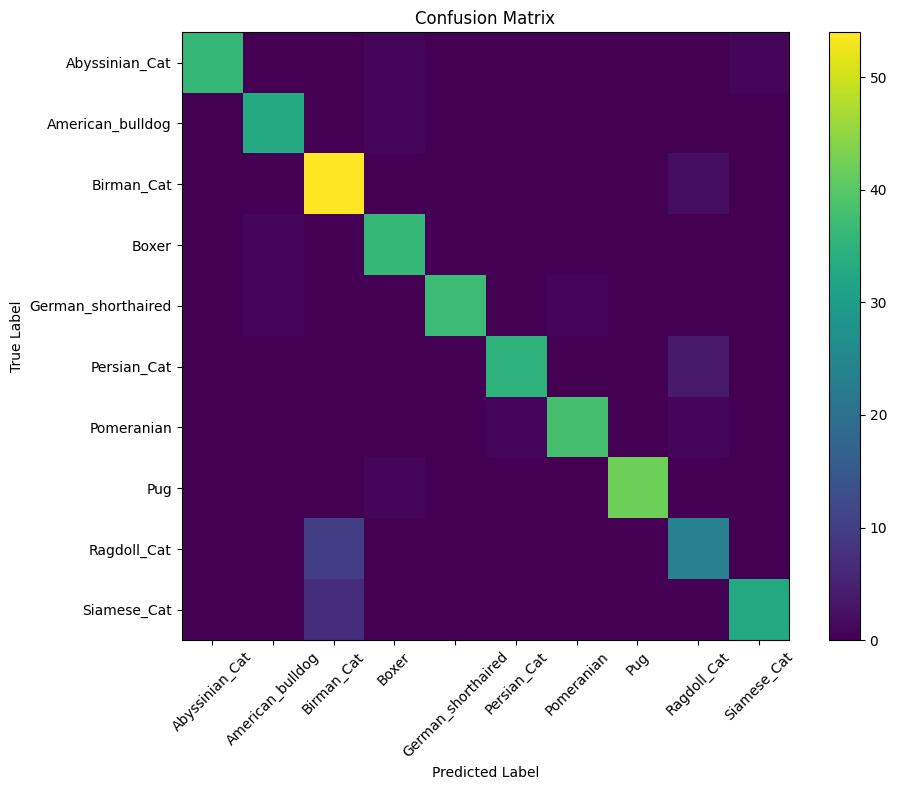

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [17]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Display metrics
print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)

# Detailed classification report
print("\nCLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)


MODEL PERFORMANCE METRICS
Accuracy:  0.9200 (92.00%)
Precision: 0.9271
Recall:    0.9200
F1-Score:  0.9208

CLASSIFICATION REPORT:
                    precision    recall  f1-score   support

    Abyssinian_Cat       1.00      0.95      0.97        38
  American_bulldog       0.94      0.97      0.96        34
        Birman_Cat       0.76      0.96      0.85        56
             Boxer       0.92      0.97      0.95        37
German_shorthaired       1.00      0.95      0.97        39
       Persian_Cat       0.97      0.90      0.93        39
        Pomeranian       0.97      0.95      0.96        40
               Pug       1.00      0.98      0.99        43
       Ragdoll_Cat       0.77      0.71      0.74        34
       Siamese_Cat       0.97      0.82      0.89        40

          accuracy                           0.92       400
         macro avg       0.93      0.92      0.92       400
      weighted avg       0.93      0.92      0.92       400

